# 10 発展課題（自作） 解答 — 共転写制御
対象: [`notebooks/10_cotranscriptional.ipynb`](../notebooks/10_cotranscriptional.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
M,S,MS,P = (Species(x) for x in ['m','s','ms','p'])
A_M,B_M,K_X,B_P = 60.,0.2,2.,0.008
A_S,B_S,K_ON,K_OFF,B_MS = 15.,0.1,0.002,0.05,0.4
SP=['s','m','ms','p']
def R(a,b,k): return ReactionRule(a,b,k)
def build(a_m_factor=1.0, k_xs=0.2, has_srna=True):
    mdl=NetworkModel()
    for r in [R([],[M],A_M*a_m_factor),R([M],[],B_M),R([M],[M,P],K_X),R([P],[],B_P)]:
        mdl.add_reaction_rule(r)
    if has_srna:
        for r in [R([],[S],A_S),R([S],[],B_S),R([M,S],[MS],K_ON),R([MS],[M,S],K_OFF),R([MS],[],B_MS),R([MS],[MS,P],k_xs)]:
            mdl.add_reaction_rule(r)
    return mdl
def endpoint(a_m_factor=1.0, k_xs=0.2, has_srna=True, s0=150.0, t=25.0):
    y0={'s':s0} if has_srna else {}
    a=run_simulation(t,y0=y0,model=build(a_m_factor,k_xs,has_srna),solver='ode',ndiv=100,species_list=SP).as_array()
    return a
base_p = endpoint(has_srna=False)[-1][4]   # protein without sRNA

## Q1. `P_CO` を 1.0→0.2 に振ると抑制の深さは? 実測 0.46 はどのあたり?

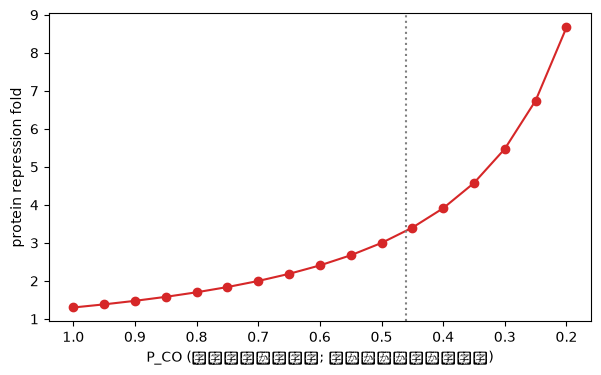

P_CO=1.0(post のみ) fold=1.30 / P_CO=0.46(実測) fold=3.31 / P_CO=0.2 fold=8.67


In [2]:
pco=np.linspace(1.0,0.2,17); fold=[base_p/endpoint(a_m_factor=p)[-1][4] for p in pco]
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(pco,fold,'o-',color='C3')
ax.axvline(0.46,ls=':',c='gray'); ax.invert_xaxis()
ax.set_xlabel('P_CO (実効転写の残存率; 小さいほど強い共転写)'); ax.set_ylabel('protein repression fold'); plt.show()
print(f'P_CO=1.0(post のみ) fold={fold[0]:.2f} / P_CO=0.46(実測) fold={base_p/endpoint(a_m_factor=0.46)[-1][4]:.2f} / P_CO=0.2 fold={fold[-1]:.2f}')

**答**: `P_CO` を下げる（共転写制御を強める）ほど抑制が単調に深まる。実測の **0.46 は抑制 ~3倍** のあたりで、post のみ（P_CO=1.0, ~1.3倍）では届かない深さを共転写制御が埋めている、という論文の主張に対応する。

## Q2. `K_XS`=0 にすると mRNA と protein の抑制比はどうずれる?

In [3]:
base_m = endpoint(has_srna=False)[-1][2]
for k_xs in [0.2, 0.0]:
    a=endpoint(a_m_factor=0.46, k_xs=k_xs)[-1]
    print(f'K_XS={k_xs}:  mRNA repression={base_m/a[2]:.2f}x   protein repression={base_p/a[4]:.2f}x')

K_XS=0.2:  mRNA repression=3.35x   protein repression=3.31x
K_XS=0.0:  mRNA repression=3.35x   protein repression=3.42x


**答**: `K_XS`=0（結合 mRNA が全く翻訳されない）にすると **mRNA 抑制はほぼ不変だが protein 抑制が深くなる**。これは「翻訳阻害」と「mRNA 分解」の寄与を分離して見せる: mRNA レベルの低下は主に分解(B_MS)由来、protein のさらなる低下は結合 mRNA の翻訳停止(K_XS→0)由来。両者は独立に効く。

## Q3. sRNA を t=0 で「オン」にする動的シナリオ

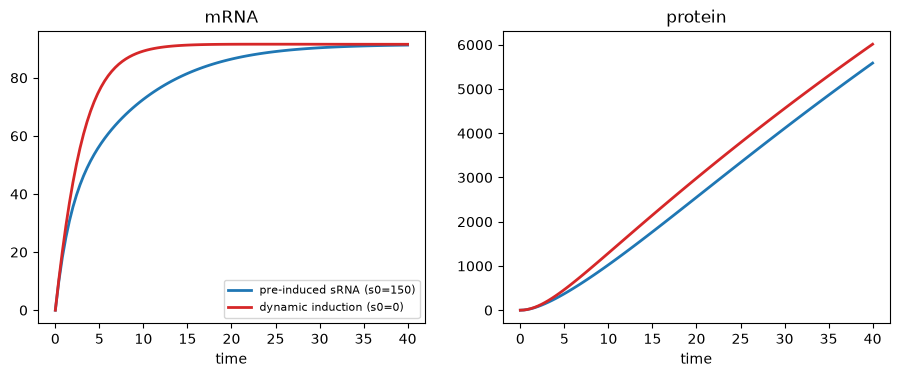

In [4]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(11,3.8))
for s0,c,lab in [(150.,'C0','pre-induced sRNA (s0=150)'),(0.,'C3','dynamic induction (s0=0)')]:
    a=endpoint(a_m_factor=0.46, s0=s0, t=40.0)
    ax1.plot(a[:,0],a[:,2],color=c,lw=2,label=lab); ax2.plot(a[:,0],a[:,4],color=c,lw=2,label=lab)
ax1.set_title('mRNA'); ax2.set_title('protein'); ax1.set_xlabel('time'); ax2.set_xlabel('time'); ax1.legend(fontsize=8); plt.show()

**答**: sRNA を 0 から誘導（動的）すると、sRNA が蓄積するまで抑制が始まらず、**応答に立ち上がりの遅れ**が出る（pre-induced 版より抑制の到達が遅い）。定常の抑制深さは同じでも、時間軸では sRNA induction の速さが応答の速さを決める。

## Q4.（考察）bio-a: 共転写制御は Rho 依存終結に依存

**答（考察）**: 共転写制御は sRNA 結合が転写途中の mRNA に Rho 依存終結を促すことで生じる。標的の配列（Rho utilization site, RUT）や sRNA 結合位置の系統差が「post だけか co も効くか」を左右する。オーソログ/標的間でこの様式が違えば、同じ sRNA でも抑制の深さ（＝co の寄与）が変わると予測できる。系統ごとの制御様式は bio-e で（ただし本モデルは Hfq 面より転写機構寄りの特徴が要るので、bio-e の枠組みを拡張する候補）。